In [1]:
import pandas as pd

In [2]:
data = pd.read_csv("Indian_Kids_Screen_Time.csv")


In [3]:
print(data)

      Age  Gender  Avg_Daily_Screen_Time_hr Primary_Device  \
0      14    Male                      3.99     Smartphone   
1      11  Female                      4.61         Laptop   
2      18  Female                      3.73             TV   
3      15  Female                      1.21         Laptop   
4      12  Female                      5.89     Smartphone   
...   ...     ...                       ...            ...   
9707   17    Male                      3.26     Smartphone   
9708   17  Female                      4.43     Smartphone   
9709   16    Male                      5.62     Smartphone   
9710   17    Male                      5.60             TV   
9711   15  Female                      6.12             TV   

      Exceeded_Recommended_Limit  Educational_to_Recreational_Ratio  \
0                           True                               0.42   
1                           True                               0.30   
2                           True          

In [4]:
data.isnull().sum()


Age                                     0
Gender                                  0
Avg_Daily_Screen_Time_hr                0
Primary_Device                          0
Exceeded_Recommended_Limit              0
Educational_to_Recreational_Ratio       0
Health_Impacts                       3218
Urban_or_Rural                          0
dtype: int64

In [5]:
data["Health_Impacts"]=data["Health_Impacts"].fillna("No health impact")

In [6]:
print(data)

      Age  Gender  Avg_Daily_Screen_Time_hr Primary_Device  \
0      14    Male                      3.99     Smartphone   
1      11  Female                      4.61         Laptop   
2      18  Female                      3.73             TV   
3      15  Female                      1.21         Laptop   
4      12  Female                      5.89     Smartphone   
...   ...     ...                       ...            ...   
9707   17    Male                      3.26     Smartphone   
9708   17  Female                      4.43     Smartphone   
9709   16    Male                      5.62     Smartphone   
9710   17    Male                      5.60             TV   
9711   15  Female                      6.12             TV   

      Exceeded_Recommended_Limit  Educational_to_Recreational_Ratio  \
0                           True                               0.42   
1                           True                               0.30   
2                           True          

In [110]:
# Derived Columns
# Age Band using Age column

data["Age_Band"] = pd.cut(
    data["Age"],
    bins=[5, 8, 12, 16],
    labels=['Young Kids', 'Pre-Teens', 'Teenagers']
)
print(data["Age_Band"].value_counts())

Age_Band
Teenagers     3546
Pre-Teens     3495
Young Kids     912
Name: count, dtype: int64


In [114]:
# percentage of kids who exceeded limit in each age group

print(data.groupby("Age_Band", observed=True)["Exceeded_Recommended_Limit"].mean()* 100)

Age_Band
Young Kids    75.000000
Pre-Teens     81.430615
Teenagers     90.045121
Name: Exceeded_Recommended_Limit, dtype: float64


In [118]:
# Screen Time Category
# Low (0–2 hrs) Moderate (2–4 hrs) High (4–6 hrs) Very High (>6 hrs)

data["Screen_Time_Level"] = pd.cut(
    data["Avg_Daily_Screen_Time_hr"],
    bins=[0, 2, 4, 6, 10],
    labels=["Low", "Moderate", "High", "Very High"]
)
data[["Avg_Daily_Screen_Time_hr", "Screen_Time_Level"]].head()

,Avg_Daily_Screen_Time_hr,Screen_Time_Level
0,3.99,Moderate
1,4.61,High
2,3.73,Moderate
3,1.21,Low
4,5.89,High


In [120]:
# counting of kids in screen time level

data["Screen_Time_Level"].value_counts()

Screen_Time_Level
High         4596
Moderate     2930
Very High    1326
Low           606
Name: count, dtype: int64

In [124]:
# Risk Level categorical column using Exceeded_Recommended_Limit column

data["Risk_Level"] = data["Exceeded_Recommended_Limit"].apply(
    lambda x: "At Risk" if x else "Safe"
)
print(data[["Exceeded_Recommended_Limit", "Risk_Level"]].head())

   Exceeded_Recommended_Limit Risk_Level
0                        True    At Risk
1                        True    At Risk
2                        True    At Risk
3                       False       Safe
4                        True    At Risk


In [128]:
print(data["Risk_Level"].value_counts())

Risk_Level
At Risk    8301
Safe       1411
Name: count, dtype: int64


In [130]:
# Health_Severity derived col using Health_Impacts col

data["Health_Severity"] = data["Health_Impacts"].apply(
    lambda x: "No Impact" if x == "No Health Impact"
    else "Mild" if len(str(x).split(",")) == 1
    else "Moderate" if len(str(x).split(",")) == 2
    else "Severe"
)
print(data[["Health_Impacts", "Health_Severity"]].head())

           Health_Impacts Health_Severity
0  Poor Sleep, Eye Strain        Moderate
1              Poor Sleep            Mild
2              Poor Sleep            Mild
3        No health impact            Mild
4     Poor Sleep, Anxiety        Moderate


In [134]:
# counting of kids in health condition based

print(data["Health_Severity"].value_counts())

Health_Severity
Mild        6767
Moderate    2349
Severe       596
Name: count, dtype: int64


In [136]:
# Digital_Balance
data["Digital_Balance"] = data["Educational_to_Recreational_Ratio"].apply(
    lambda x: "Balanced" if x == 1
    else "Mostly Recreational" if x < 0.5
    else "Moderately Recreational"
)
print(data[["Educational_to_Recreational_Ratio", "Digital_Balance"]].head())

   Educational_to_Recreational_Ratio      Digital_Balance
0                               0.42  Mostly Recreational
1                               0.30  Mostly Recreational
2                               0.32  Mostly Recreational
3                               0.39  Mostly Recreational
4                               0.49  Mostly Recreational


In [140]:
print(data["Digital_Balance"].value_counts())

Digital_Balance
Mostly Recreational        8115
Moderately Recreational    1597
Name: count, dtype: int64


In [142]:
# creating Screen_Size_Type derived col using primary device col

data["Screen_Size_Type"] = data["Primary_Device"].apply(
    lambda x: "Small Screen" if x.lower() == "smartphone"
    else "Medium Screen" if x.lower() == "tablet"
    else "Large Screen"
)
data[["Primary_Device", "Screen_Size_Type"]].head()

,Primary_Device,Screen_Size_Type
0,Smartphone,Small Screen
1,Laptop,Large Screen
2,TV,Large Screen
3,Laptop,Large Screen
4,Smartphone,Small Screen


In [144]:
# weekday | weekend derived col

data["Day_Type"] = data["Avg_Daily_Screen_Time_hr"].apply(
    lambda x: "Weekend" if x > 3 else "Weekday"
)

data["Day_Type"].value_counts()

Day_Type
Weekend    7959
Weekday    1753
Name: count, dtype: int64

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

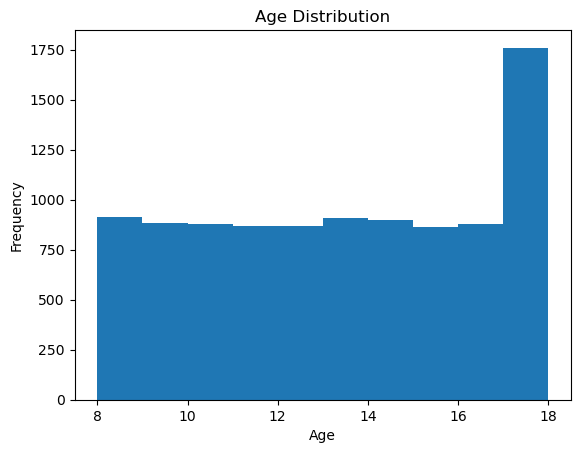

In [38]:
#univariate
#age-histogram
plt.figure()
plt.hist(data["Age"], bins=10)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

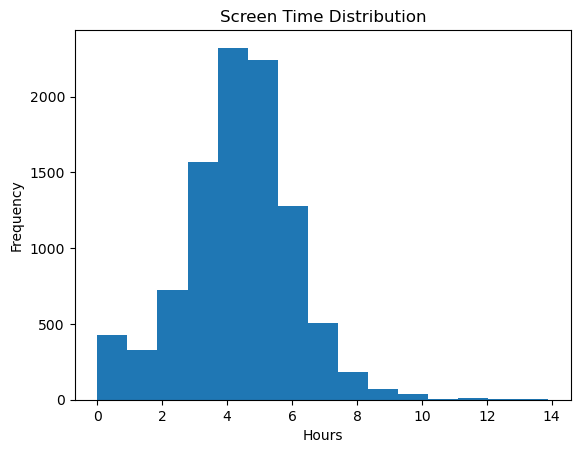

In [39]:
#average daily screentime-histogram 
plt.figure()
plt.hist(data["Avg_Daily_Screen_Time_hr"], bins=15)
plt.title("Screen Time Distribution")
plt.xlabel("Hours")
plt.ylabel("Frequency")
plt.show()

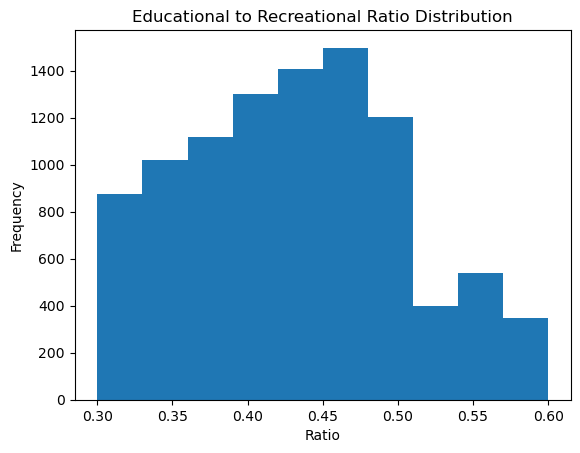

In [40]:
#educational to recreatinal ratio-histogram
plt.figure()
plt.hist(data["Educational_to_Recreational_Ratio"], bins=10)
plt.title("Educational to Recreational Ratio Distribution")
plt.xlabel("Ratio")
plt.ylabel("Frequency")
plt.show()

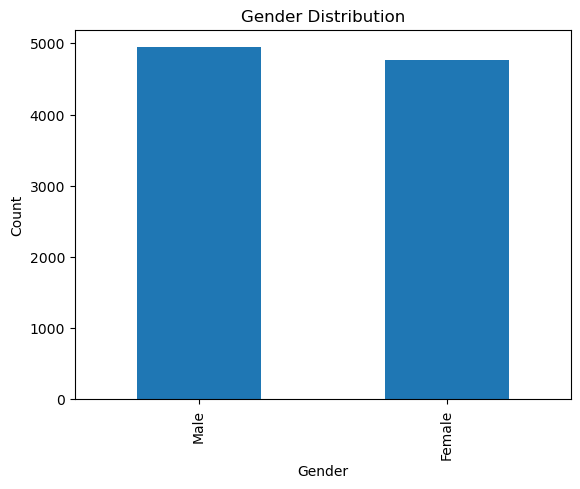

In [41]:
#gender-bar chart
plt.figure()
data["Gender"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

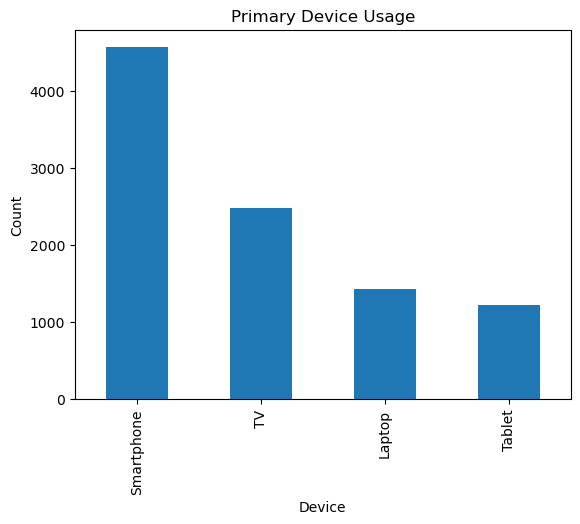

In [42]:
#primary device-barchart
plt.figure()
data["Primary_Device"].value_counts().plot(kind="bar")
plt.title("Primary Device Usage")
plt.xlabel("Device")
plt.ylabel("Count")
plt.show()

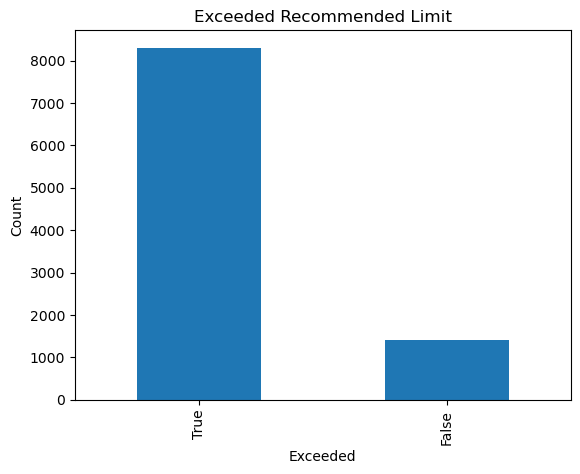

In [43]:
#exceeded recommended limit-bar chart
plt.figure()
data["Exceeded_Recommended_Limit"].value_counts().plot(kind="bar")
plt.title("Exceeded Recommended Limit")
plt.xlabel("Exceeded")
plt.ylabel("Count")
plt.show()

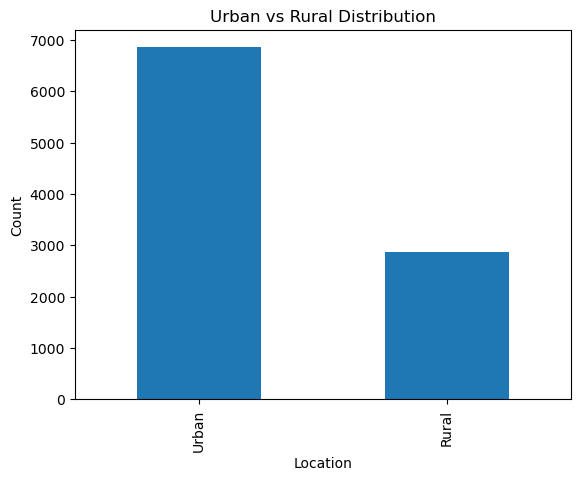

In [44]:
#urban vs rural-barchart
plt.figure()
data["Urban_or_Rural"].value_counts().plot(kind="bar")
plt.title("Urban vs Rural Distribution")
plt.xlabel("Location")
plt.ylabel("Count")
plt.show()

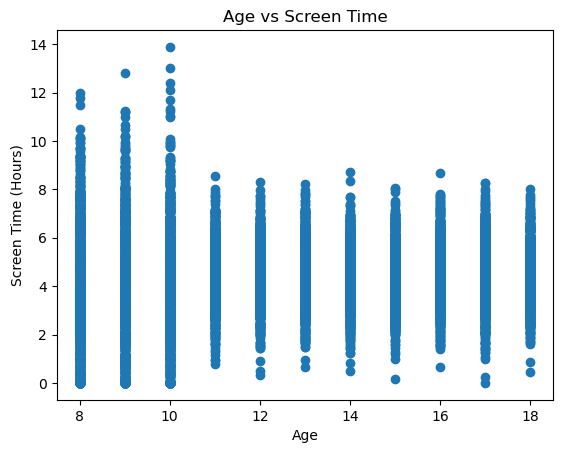

In [45]:
#bivariate analysis
#age vs screentime-scatter
plt.figure()
plt.scatter(data["Age"], data["Avg_Daily_Screen_Time_hr"])
plt.title("Age vs Screen Time")
plt.xlabel("Age")
plt.ylabel("Screen Time (Hours)")
plt.show()

<Figure size 640x480 with 0 Axes>

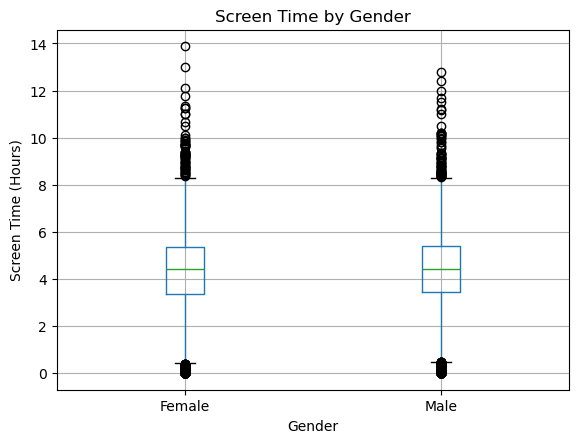

In [47]:
#Gender vs Screen Time (Boxplot)
plt.figure()
data.boxplot(column="Avg_Daily_Screen_Time_hr", by="Gender")
plt.title("Screen Time by Gender")
plt.suptitle("")
plt.xlabel("Gender")
plt.ylabel("Screen Time (Hours)")
plt.show()

<Figure size 640x480 with 0 Axes>

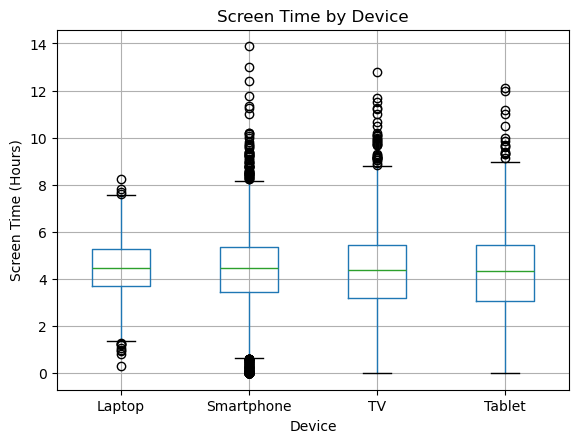

In [48]:
#Device vs Screen Time (Boxplot)
plt.figure()
data.boxplot(column="Avg_Daily_Screen_Time_hr", by="Primary_Device")
plt.title("Screen Time by Device")
plt.suptitle("")
plt.xlabel("Device")
plt.ylabel("Screen Time (Hours)")
plt.show()

<Figure size 640x480 with 0 Axes>

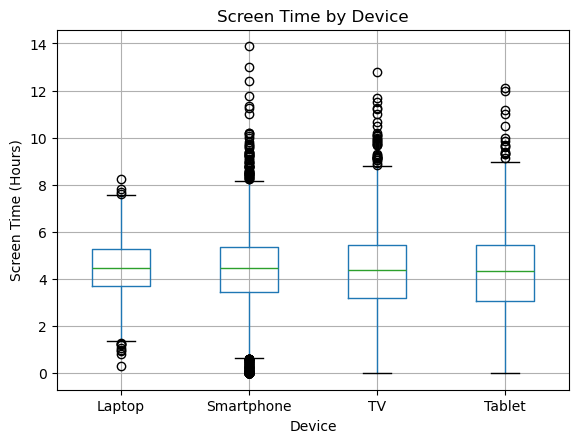

In [50]:
#Urban/Rural vs Screen Time (Boxplot)
plt.figure()
data.boxplot(column="Avg_Daily_Screen_Time_hr", by="Primary_Device")
plt.title("Screen Time by Device")
plt.suptitle("")
plt.xlabel("Device")
plt.ylabel("Screen Time (Hours)")
plt.show()

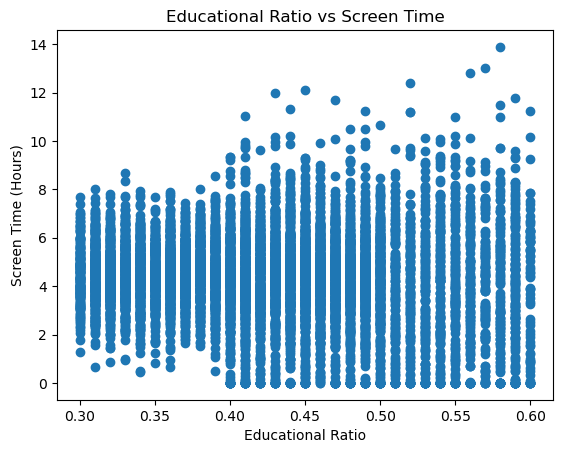

In [51]:
#Educational Ratio vs Screen Time (Scatter)
plt.figure()
plt.scatter(data["Educational_to_Recreational_Ratio"],
            data["Avg_Daily_Screen_Time_hr"])
plt.title("Educational Ratio vs Screen Time")
plt.xlabel("Educational Ratio")
plt.ylabel("Screen Time (Hours)")
plt.show()

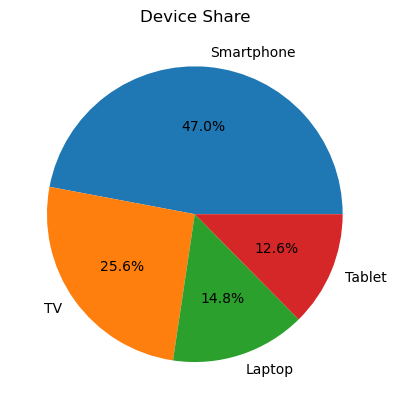

In [53]:
#For Categorical Columns (Gender, Device, Location)
#Pie Chart
data["Primary_Device"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Device Share")
plt.ylabel("")
plt.show()

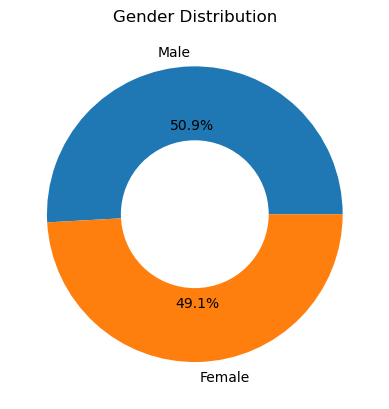

In [55]:
#Donut Chart
counts = data["Gender"].value_counts()

plt.pie(counts, labels=counts.index, autopct="%1.1f%%")
centre_circle = plt.Circle((0,0),0.50,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title("Gender Distribution")
plt.show()

In [57]:
data.to_csv('cleaned_data.csv', index=False)

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("cleaned_data.csv")
data.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Band,Day_Type,Device_Share,Educational_Share,Recreational_Share,Device_Type,Device_Type_Share,Device_Group
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,14-16,Weekday,0.470346,0.42,0.58,Portable,0.743925,Handheld
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban,11-13,Weekday,0.147549,0.30,0.70,Portable,0.743925,Computer
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban,17-18,Weekday,0.256075,0.32,0.68,Wallmount,0.256075,Television
3,15,Female,1.21,Laptop,False,0.39,No health impact,Urban,14-16,Weekend,0.147549,0.39,0.61,Portable,0.743925,Computer
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,11-13,Weekday,0.470346,0.49,0.51,Portable,0.743925,Handheld


In [60]:
#UNIVARIATE ANALYSIS
 #Numerical Columns
num_cols = data.select_dtypes(include=["int64","float64"]).columns
num_cols

Index(['Age', 'Avg_Daily_Screen_Time_hr', 'Educational_to_Recreational_Ratio',
       'Device_Share', 'Educational_Share', 'Recreational_Share',
       'Device_Type_Share'],
      dtype='object')

In [62]:
#Summary Statistics
data[num_cols].describe()

,Age,Avg_Daily_Screen_Time_hr,Educational_to_Recreational_Ratio,Device_Share,Educational_Share,Recreational_Share,Device_Type_Share
count,9712.000000,9712.000000,9712.000000,9712.000000,9712.000000,9712.000000,9712.000000
mean,12.979201,4.352837,0.427226,0.324454,0.427226,0.572774,0.618999
std,3.162437,1.718232,0.073221,0.144188,0.073221,0.073221,0.212940
min,8.000000,0.000000,0.300000,0.126030,0.300000,0.400000,0.256075
25%,10.000000,3.410000,0.370000,0.147549,0.370000,0.520000,0.256075
50%,13.000000,4.440000,0.430000,0.256075,0.430000,0.570000,0.743925
75%,16.000000,5.380000,0.480000,0.470346,0.480000,0.630000,0.743925
max,18.000000,13.890000,0.600000,0.470346,0.600000,0.700000,0.743925


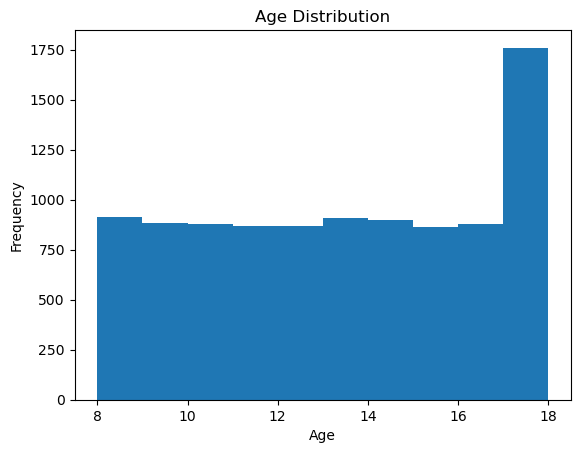

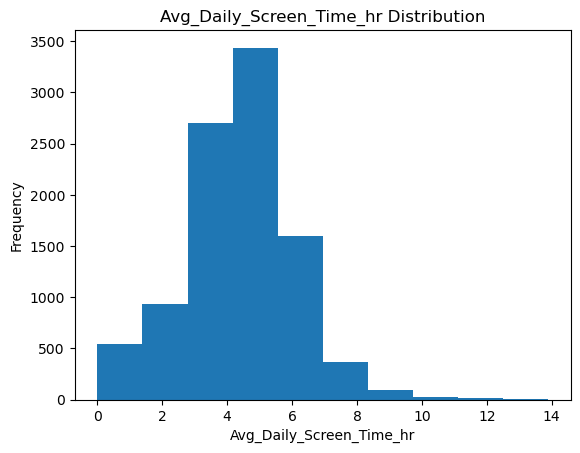

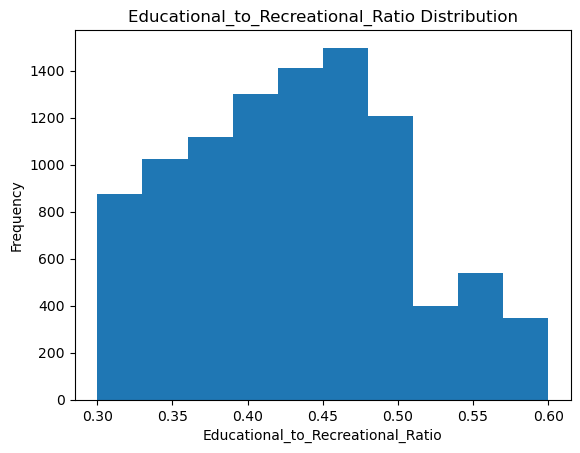

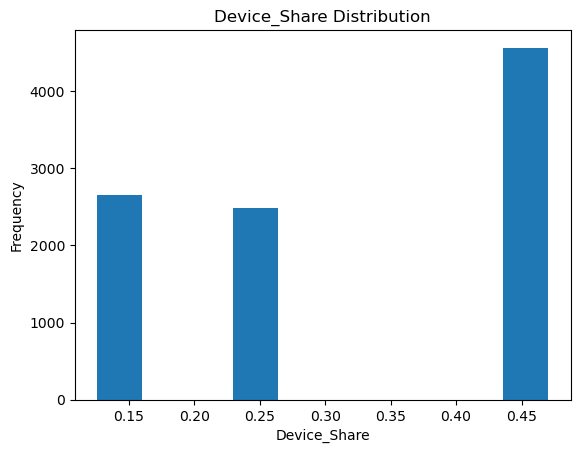

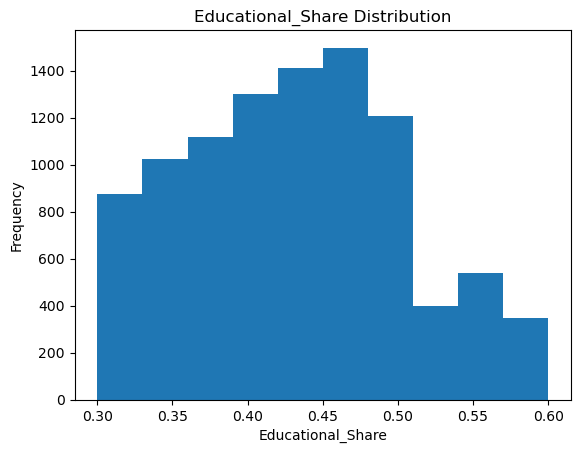

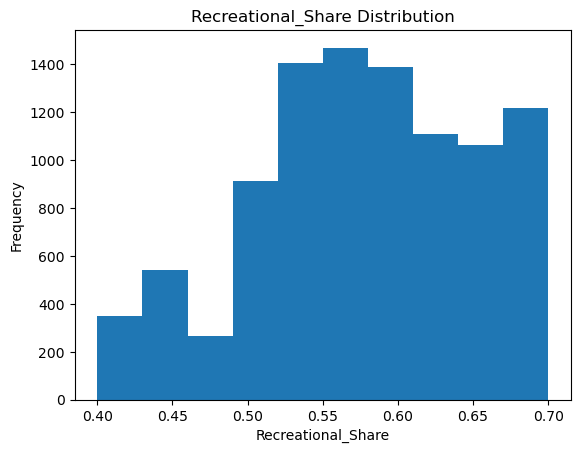

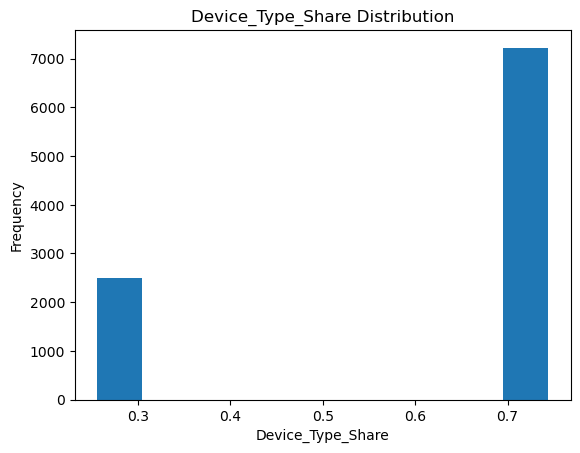

In [64]:
#Histogram (All Numerical Columns)
for col in num_cols:
    plt.figure()
    plt.hist(data[col], bins=10)
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

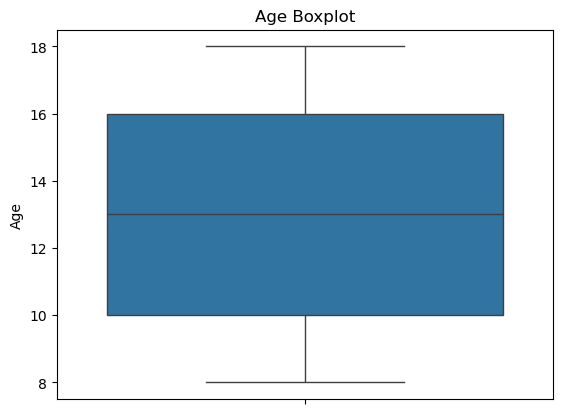

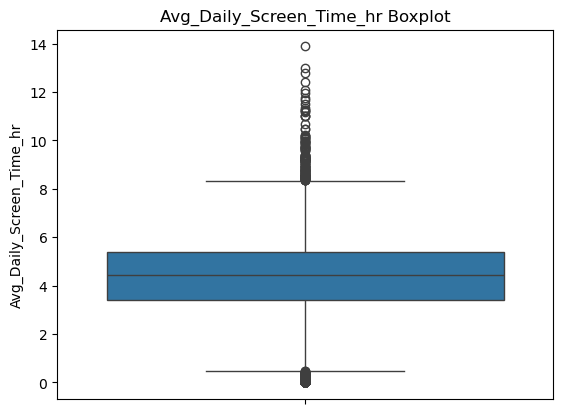

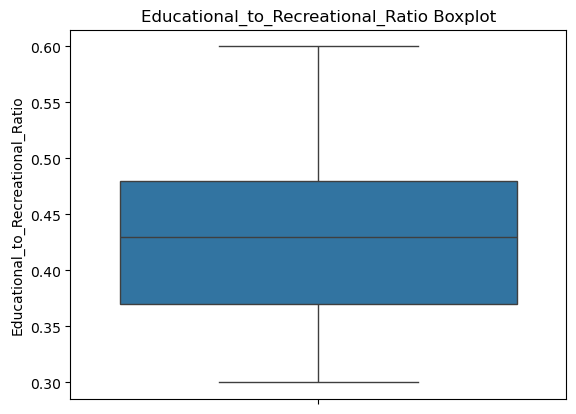

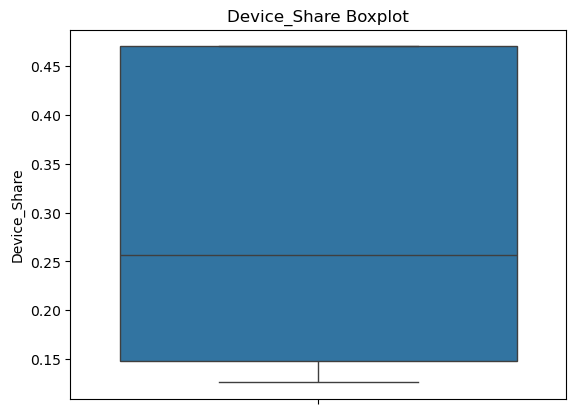

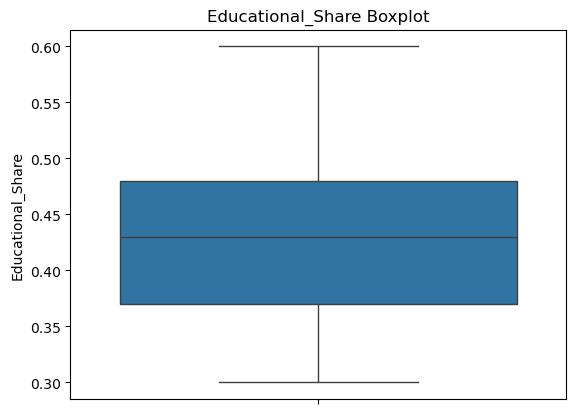

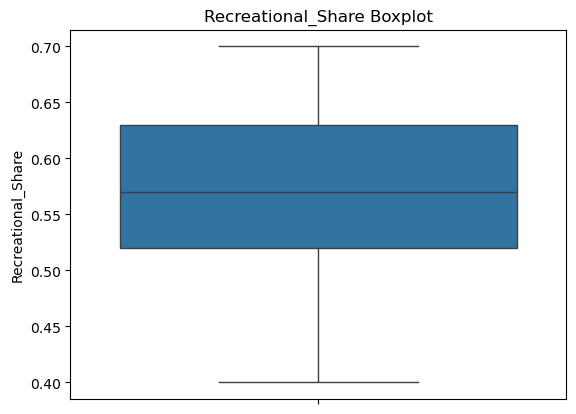

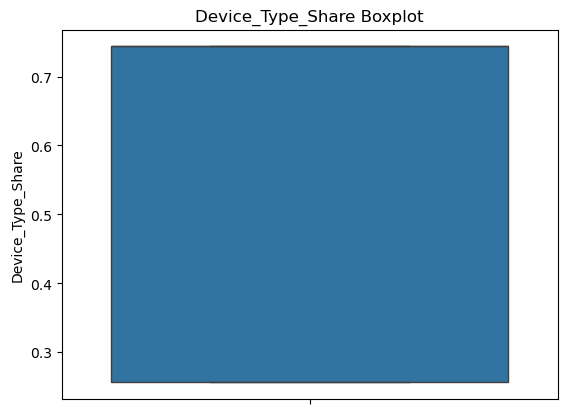

In [65]:
#Boxplot (Detect Outliers)
for col in num_cols:
    plt.figure()
    sns.boxplot(y=data[col])
    plt.title(f"{col} Boxplot")
    plt.show()

In [67]:
#Categorical Columns
cat_cols = data.select_dtypes(include=["object","bool"]).columns
cat_cols

Index(['Gender', 'Primary_Device', 'Exceeded_Recommended_Limit',
       'Health_Impacts', 'Urban_or_Rural', 'Age_Band', 'Day_Type',
       'Device_Type', 'Device_Group'],
      dtype='object')

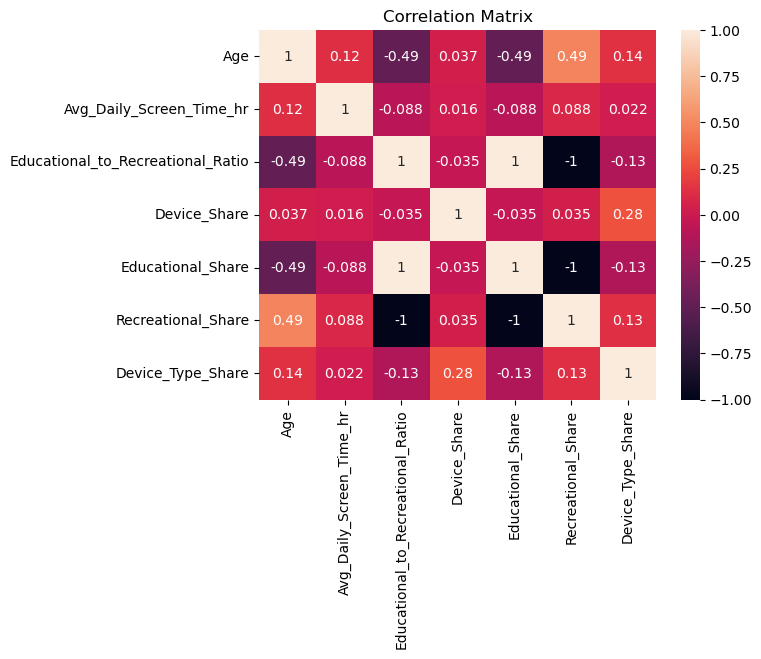

In [85]:
#BIVARIATE ANALYSIS
#Numerical vs Numerical
  #Correlation Matrix
plt.figure()
sns.heatmap(data[num_cols].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

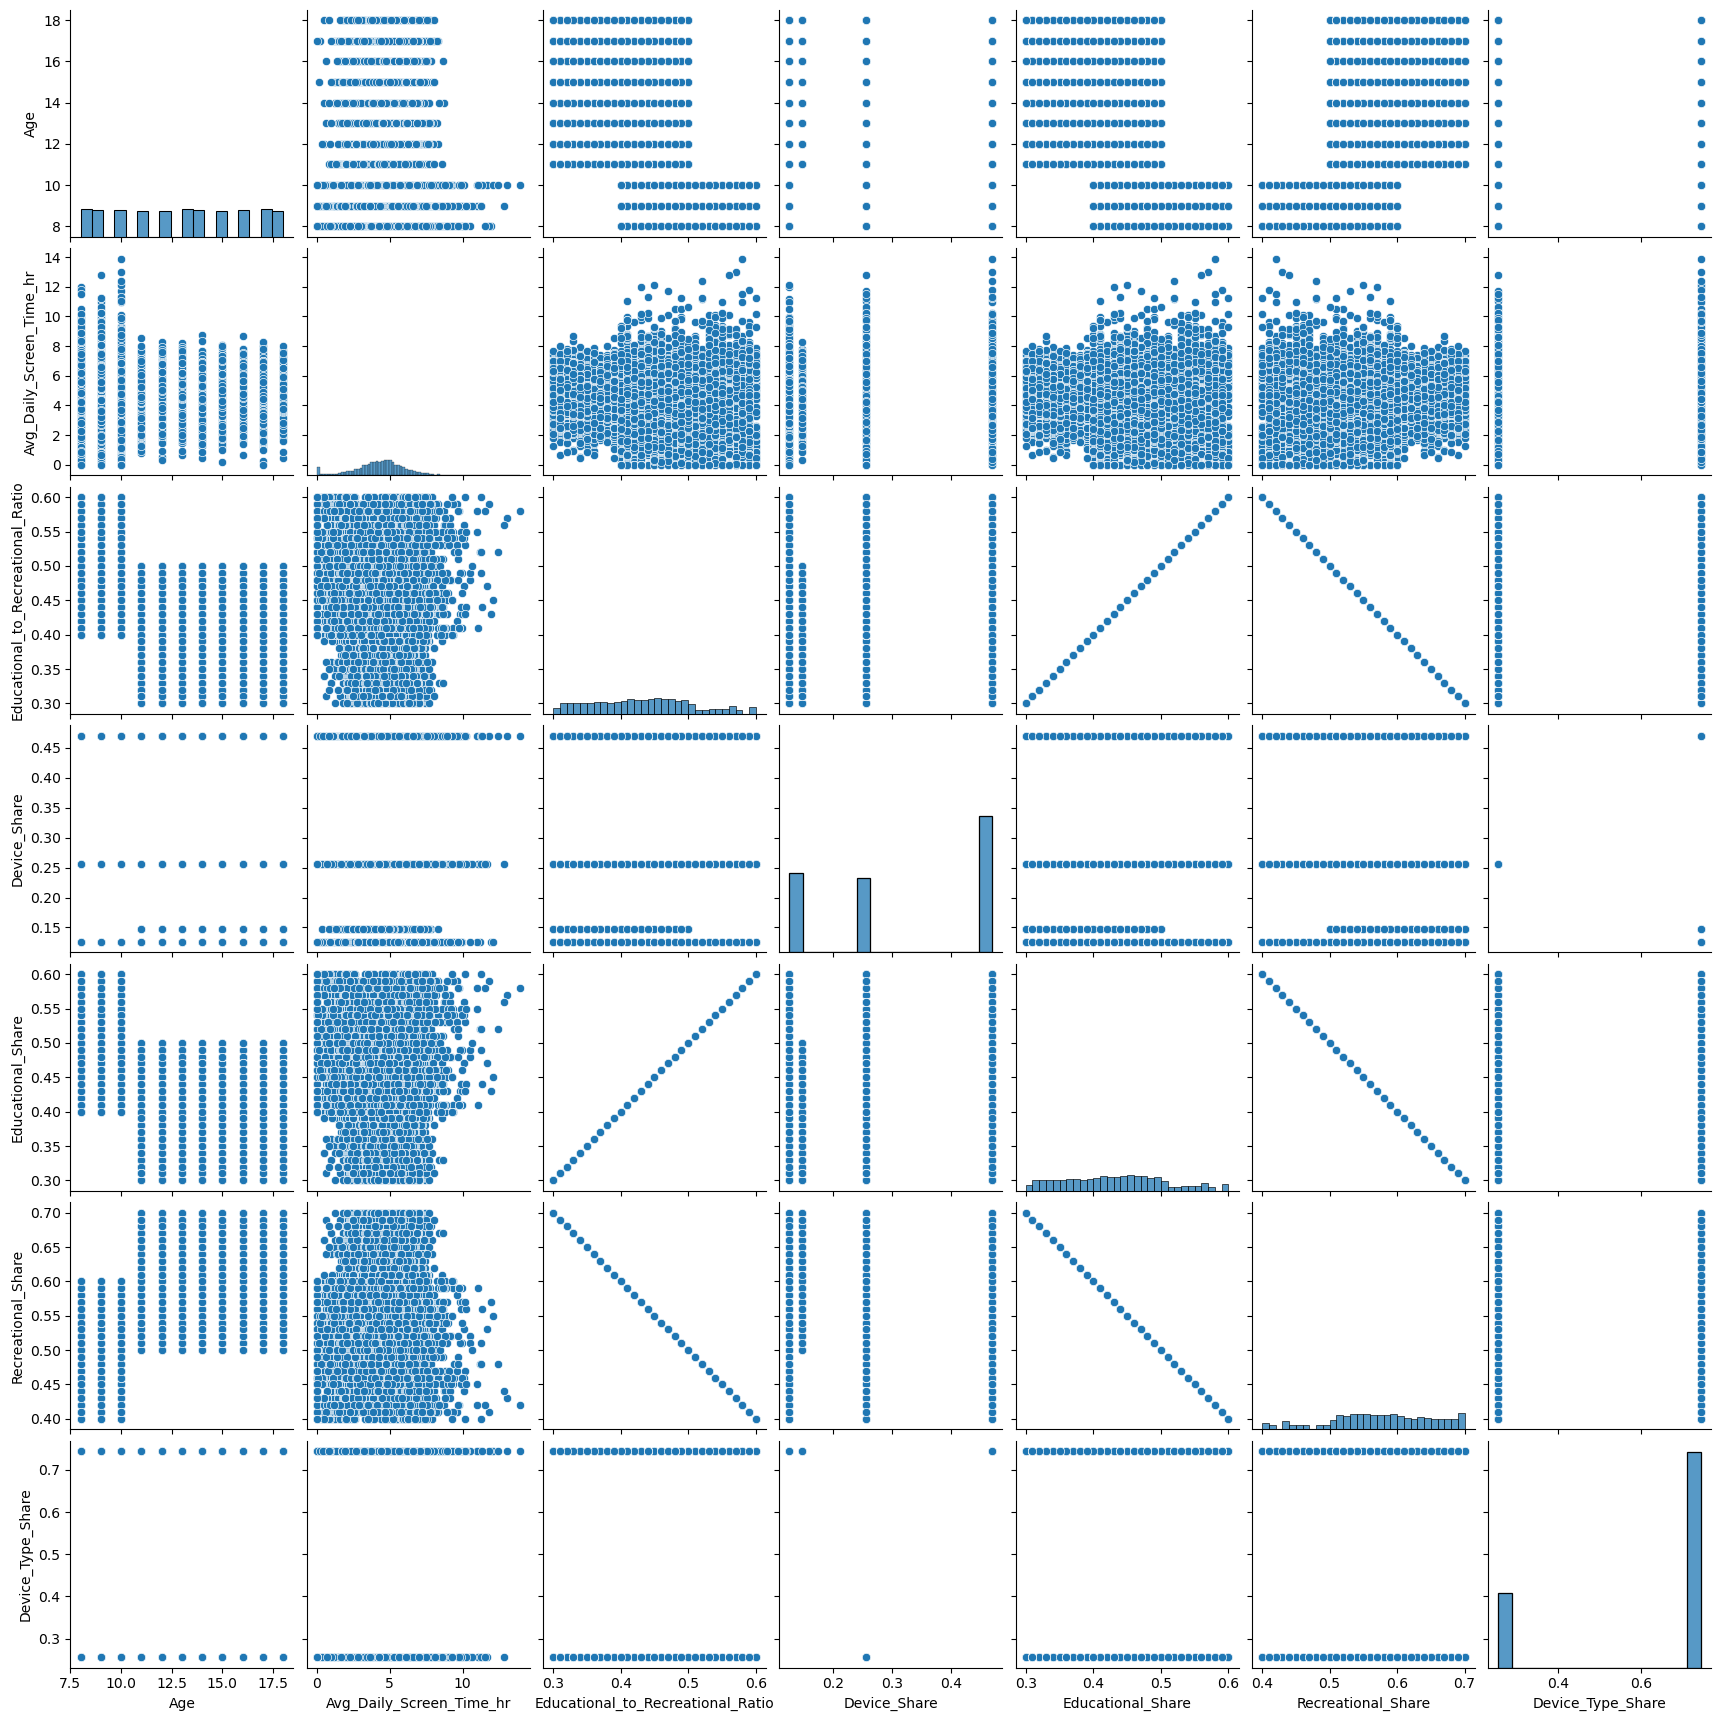

In [88]:
#Scatter Plots (All Numerical Pairs)
sns.pairplot(data[num_cols])
plt.show()

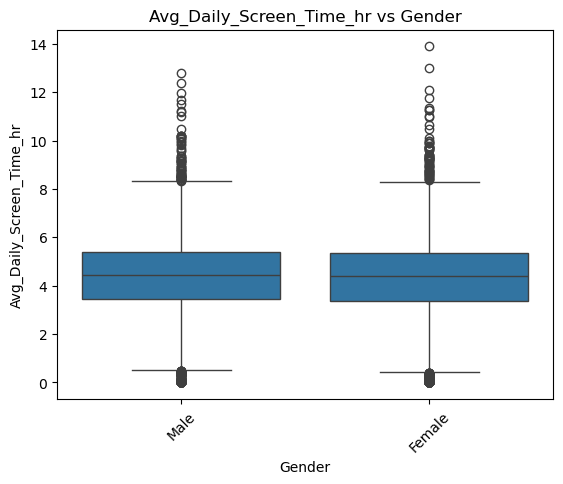

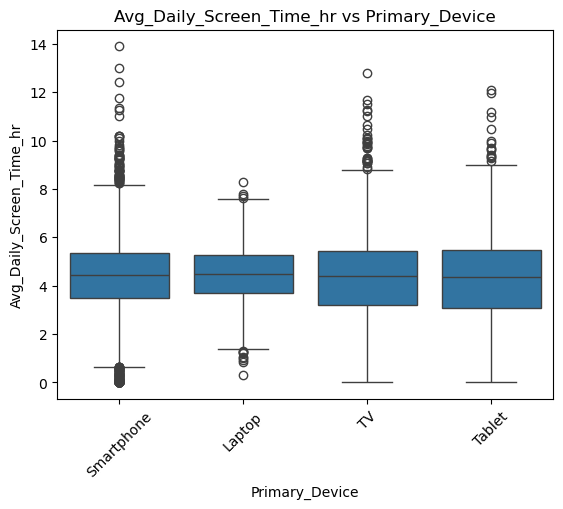

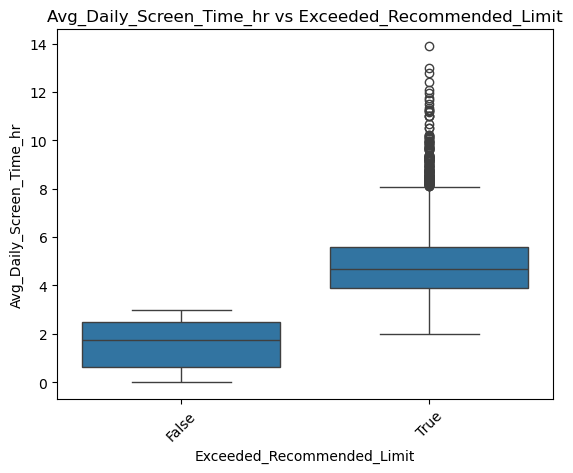

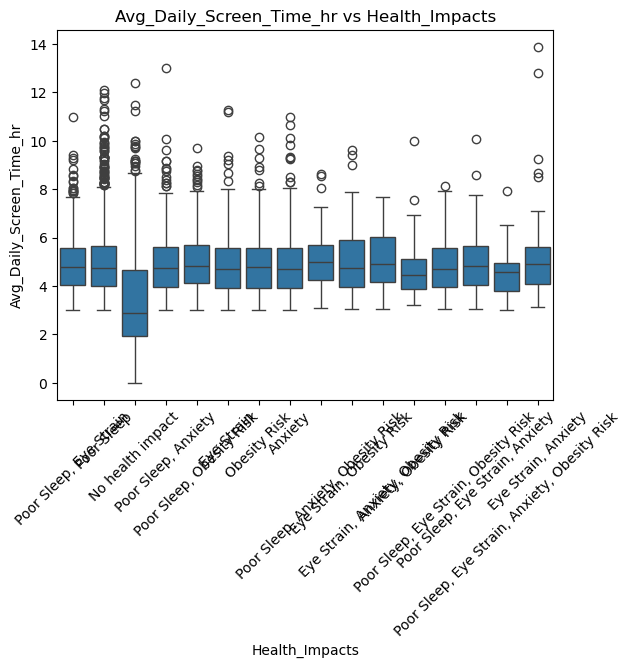

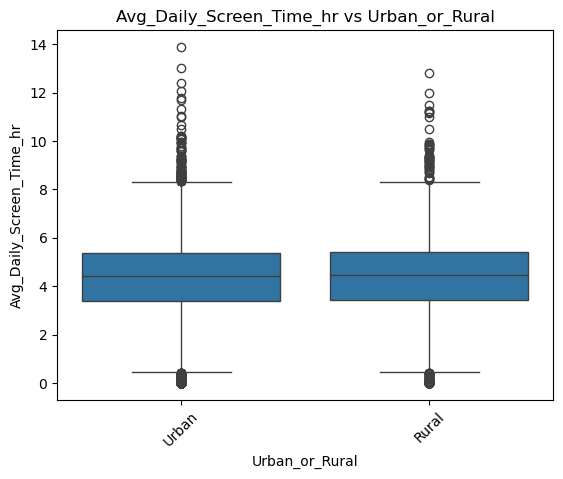

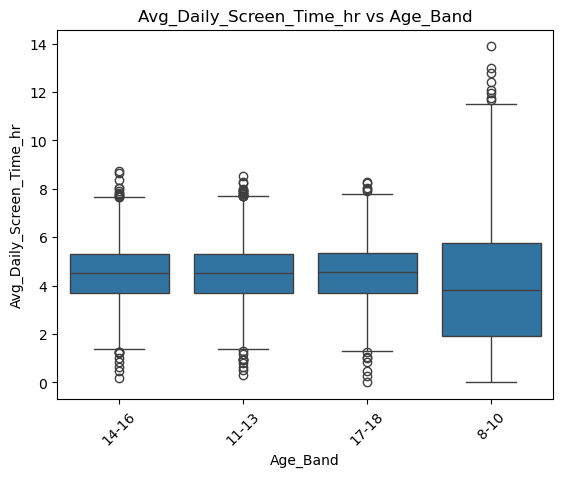

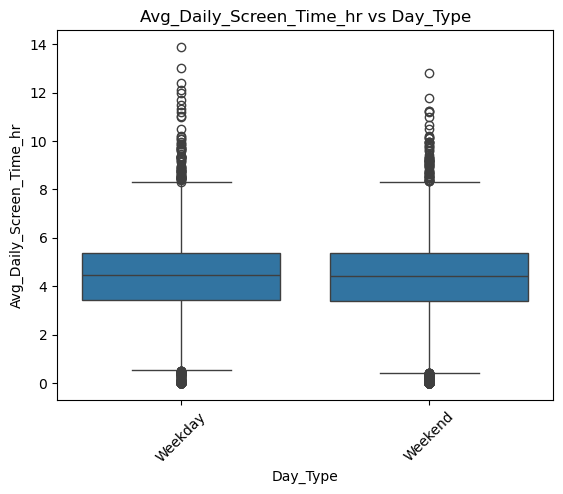

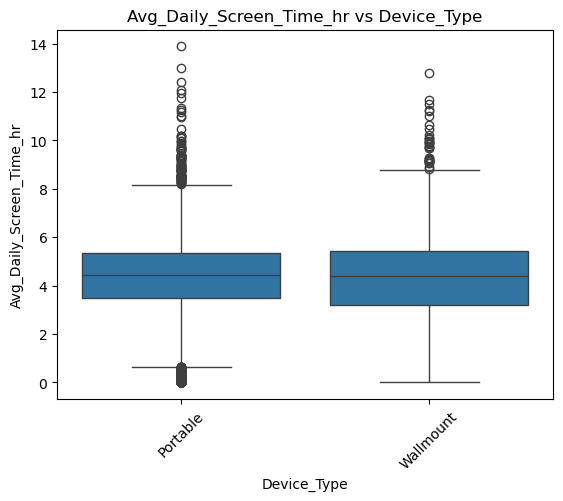

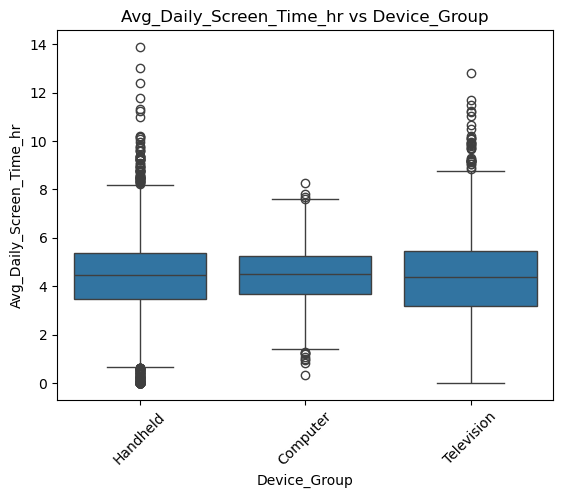

In [90]:
#Numerical vs Categorical
target = "Avg_Daily_Screen_Time_hr"  

for col in cat_cols:
    plt.figure()
    sns.boxplot(x=data[col], y=data[target])
    plt.title(f"{target} vs {col}")
    plt.xticks(rotation=45)
    plt.show()

In [92]:
#Mean Comparison
for col in cat_cols:
    print("\nAverage Screen Time by", col)
    print(data.groupby(col)[target].mean())


Average Screen Time by Gender
Gender
Female    4.327021
Male      4.377754
Name: Avg_Daily_Screen_Time_hr, dtype: float64

Average Screen Time by Primary_Device
Primary_Device
Laptop        4.459086
Smartphone    4.388925
TV            4.287752
Tablet        4.226005
Name: Avg_Daily_Screen_Time_hr, dtype: float64

Average Screen Time by Exceeded_Recommended_Limit
Exceeded_Recommended_Limit
False    1.581751
True     4.823865
Name: Avg_Daily_Screen_Time_hr, dtype: float64

Average Screen Time by Health_Impacts
Health_Impacts
Anxiety                                          4.903403
Anxiety, Obesity Risk                            4.648841
Eye Strain                                       4.809301
Eye Strain, Anxiety                              5.081185
Eye Strain, Anxiety, Obesity Risk                4.993429
Eye Strain, Obesity Risk                         4.949811
No health impact                                 3.213254
Obesity Risk                                     4.911151
Poor 

In [94]:
#Categorical vs Categorical
#Crosstab
for col in cat_cols:
    if col != cat_cols[0]:
        print("\n", cat_cols[0], "vs", col)
        print(pd.crosstab(data[cat_cols[0]], data[col]))


 Gender vs Primary_Device
Primary_Device  Laptop  Smartphone    TV  Tablet
Gender                                          
Female             741        2221  1218     590
Male               692        2347  1269     634

 Gender vs Exceeded_Recommended_Limit
Exceeded_Recommended_Limit  False  True 
Gender                                  
Female                        745   4025
Male                          666   4276

 Gender vs Health_Impacts
Health_Impacts  Anxiety  Anxiety, Obesity Risk  Eye Strain  \
Gender                                                       
Female              186                     35         324   
Male                199                     34         320   

Health_Impacts  Eye Strain, Anxiety  Eye Strain, Anxiety, Obesity Risk  \
Gender                                                                   
Female                           68                                 16   
Male                             67                                 19   

H

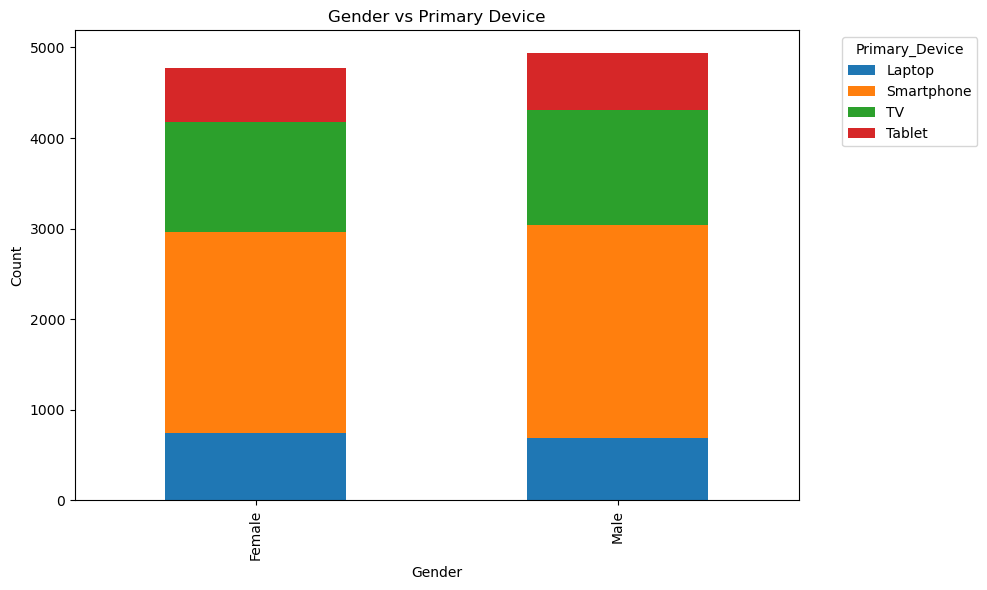

In [104]:
#stacked bar chart
ax = pd.crosstab(data["Gender"],data["Primary_Device"]).plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

ax.set_title("Gender vs Primary Device")
ax.set_xlabel("Gender")
ax.set_ylabel("Count")

ax.legend(title="Primary_Device",
          bbox_to_anchor=(1.05, 1),
          loc="upper left")

plt.tight_layout()
plt.show()